In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, detrend

# Load what we saved in Notebook 03
R = np.load("../outputs/R_signal.npy")
G = np.load("../outputs/G_signal.npy")
B = np.load("../outputs/B_signal.npy")

fps = 29.264106
t   = np.arange(len(R)) / fps

print(f"Loaded signals: {len(R)} samples @ {fps:.2f} fps")

Loaded signals: 1547 samples @ 29.26 fps


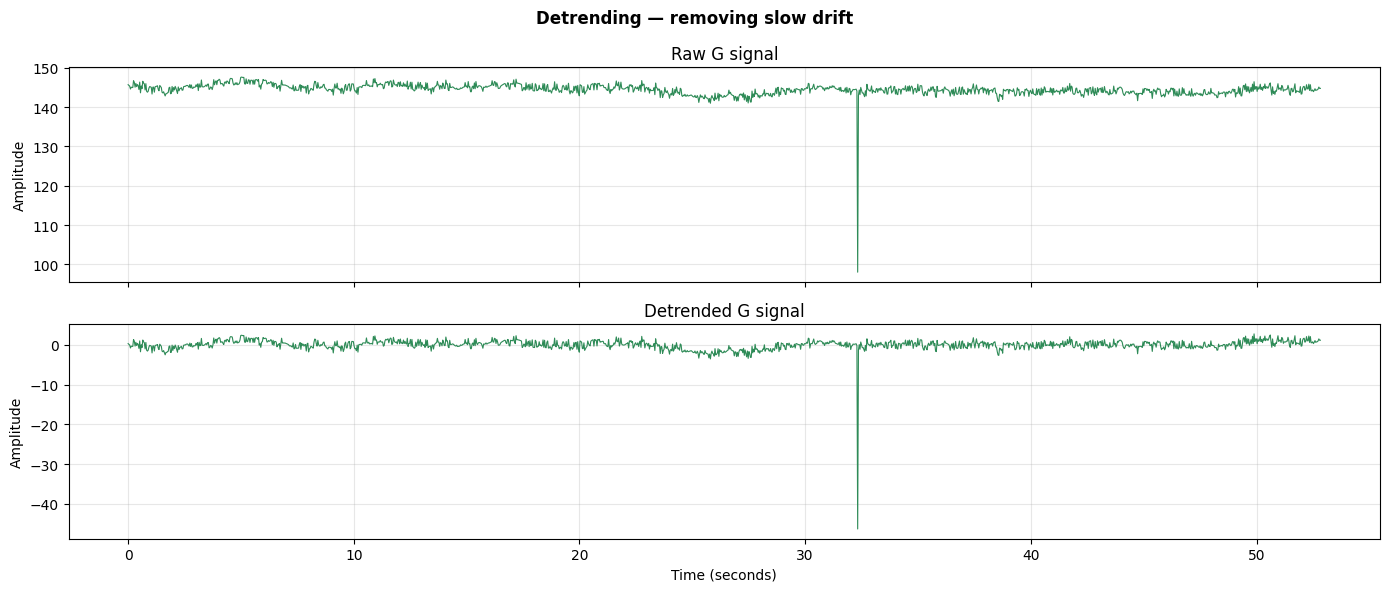

In [2]:
R_d = detrend(R)
G_d = detrend(G)
B_d = detrend(B)

# Visualize detrending effect on green channel
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
fig.suptitle("Detrending — removing slow drift", fontweight='bold')

axes[0].plot(t, G, color='seagreen', linewidth=0.8)
axes[0].set_title("Raw G signal")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, G_d, color='seagreen', linewidth=0.8)
axes[1].set_title("Detrended G signal")
axes[1].set_ylabel("Amplitude")
axes[1].set_xlabel("Time (seconds)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/detrended.png", dpi=150)
plt.show()

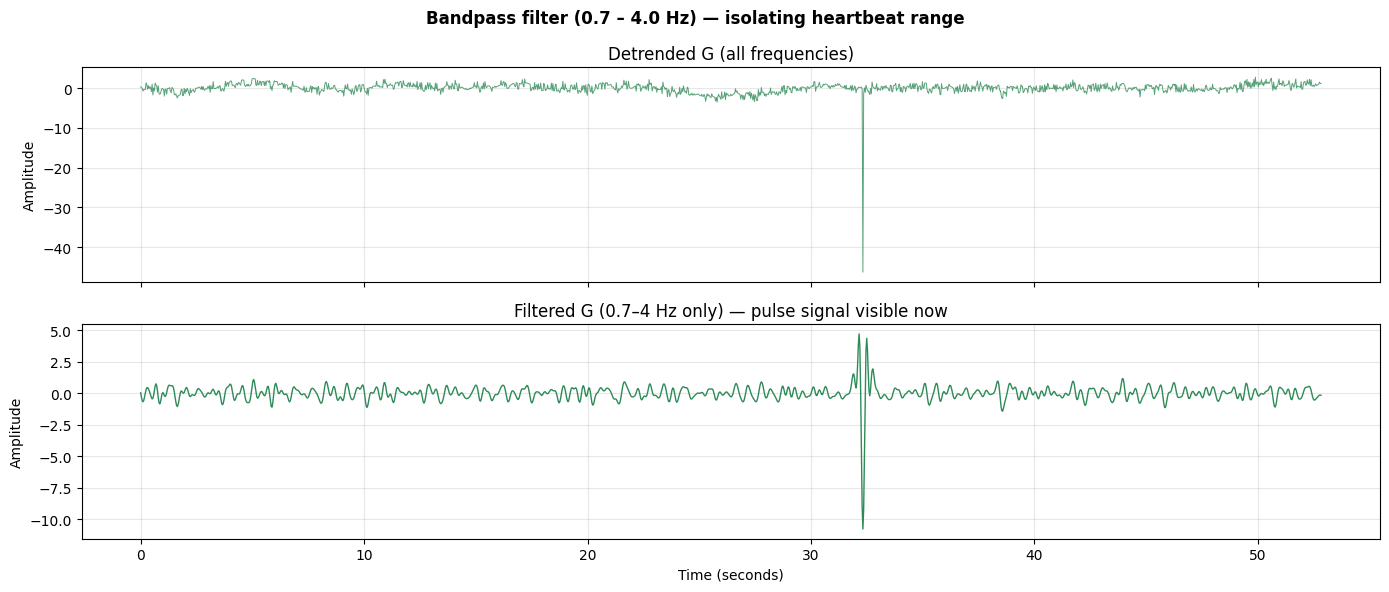

In [3]:
def bandpass_filter(signal, lowcut=0.7, highcut=4.0, fs=29.264106, order=4):
    nyq    = fs / 2
    low    = lowcut  / nyq
    high   = highcut / nyq
    b, a   = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

R_f = bandpass_filter(R_d)
G_f = bandpass_filter(G_d)
B_f = bandpass_filter(B_d)

# Show before and after on green
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
fig.suptitle("Bandpass filter (0.7 – 4.0 Hz) — isolating heartbeat range", fontweight='bold')

axes[0].plot(t, G_d, color='seagreen', linewidth=0.7, alpha=0.8)
axes[0].set_title("Detrended G (all frequencies)")
axes[0].set_ylabel("Amplitude"); axes[0].grid(True, alpha=0.3)

axes[1].plot(t, G_f, color='seagreen', linewidth=1.0)
axes[1].set_title("Filtered G (0.7–4 Hz only) — pulse signal visible now")
axes[1].set_ylabel("Amplitude"); axes[1].set_xlabel("Time (seconds)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/bandpass_filtered.png", dpi=150)
plt.show()

In [4]:
# Step 1: Normalize each channel by its mean
Rn = R_f / R_f.mean() if R_f.mean() != 0 else R_f
Gn = G_f / G_f.mean() if G_f.mean() != 0 else G_f
Bn = B_f / B_f.mean() if B_f.mean() != 0 else B_f

# Step 2: Two chrominance signals
X = 3*Rn - 2*Gn          # captures pulse + specular noise
Y = 1.5*Rn + Gn - 1.5*Bn # captures specular noise direction

# Step 3: Scale factor to cancel noise
alpha = X.std() / Y.std()

# Step 4: Final rPPG signal
rppg = X - alpha * Y

# Normalize for display
rppg = (rppg - rppg.mean()) / rppg.std()

np.save("../outputs/rppg_signal.npy", rppg)
print("rPPG signal extracted ✓")
print(f"Alpha (noise cancellation factor): {alpha:.4f}")

rPPG signal extracted ✓
Alpha (noise cancellation factor): 3.2415


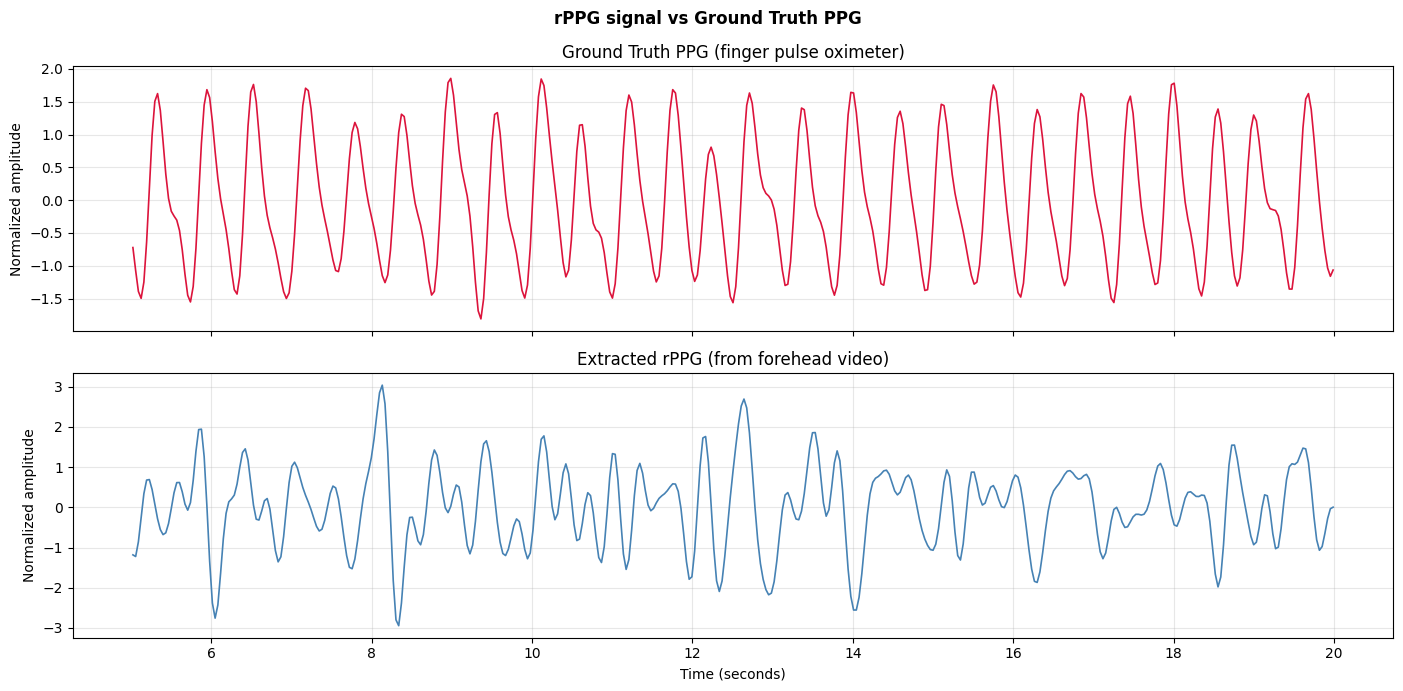

In [5]:
gt_data    = np.loadtxt("../data/subject1/ground_truth.txt")
ppg_gt     = gt_data[0]
ppg_gt     = bandpass_filter(detrend(ppg_gt))
ppg_gt     = (ppg_gt - ppg_gt.mean()) / ppg_gt.std()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle("rPPG signal vs Ground Truth PPG", fontweight='bold')

# Zoom to 15 seconds for clarity
mask = (t >= 5) & (t <= 20)

axes[0].plot(t[mask], ppg_gt[mask], color='crimson', linewidth=1.2)
axes[0].set_title("Ground Truth PPG (finger pulse oximeter)")
axes[0].set_ylabel("Normalized amplitude")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t[mask], rppg[mask], color='steelblue', linewidth=1.2)
axes[1].set_title("Extracted rPPG (from forehead video)")
axes[1].set_ylabel("Normalized amplitude")
axes[1].set_xlabel("Time (seconds)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/rppg_vs_gt.png", dpi=150)
plt.show()